# Phân tích chuyên sâu về chỉ số BMI - Pima Indians Diabetes

Notebook này được tạo để phân tích riêng về biến `bmi` trong tập dữ liệu Pima Indians Diabetes.

Trọng tâm:
- Thống kê mô tả về biến BMI
- Vấn đề Missing Values (bmi = 0)
- Phân bố của BMI theo Outcome
- Mối tương quan giữa BMI và Glucose

In [64]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [65]:
column_names = [
    "pregnancies",
    "glucose",
    "blood_pressure",
    "skin_thickness",
    "insulin",
    "bmi",
    "diabetes_pedigree_function",
    "age",
    "outcome",
]

In [66]:
repo_root = Path().resolve().parent.parent
data_path = repo_root / "Lab_03" / "data" / "pima-indians-diabetes.csv"

df = pd.read_csv(data_path, header=None, names=column_names)
df.head()

,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree_function,age,outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 1. Dữ liệu gốc (Bao gồm các giá trị 0)

Trong bộ dữ liệu gốc, bmi có chứa các giá trị 0. Về mặt sinh lý học đây là điều không thể (chỉ số khối cơ thể không thể bằng 0). Do đó số 0 ở đây thực chất là dữ liệu bị thiếu (missing value).

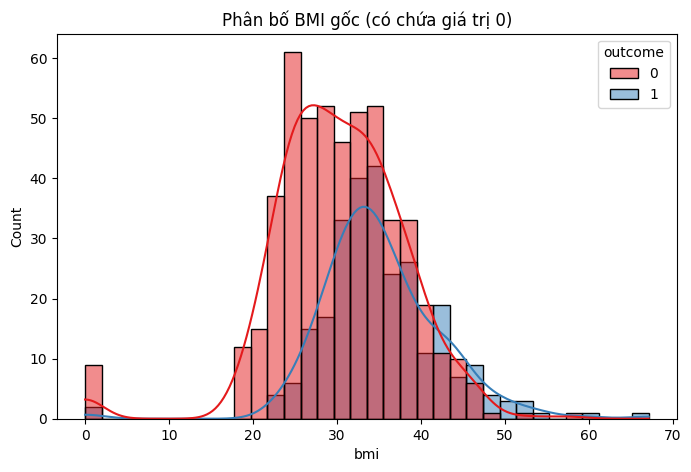

In [67]:
fig_raw, ax_raw = plt.subplots(figsize=(8, 5))
sns.histplot(
    data=df, 
    x="bmi", 
    hue="outcome", 
    kde=True, 
    ax=ax_raw,
    palette="Set1"
)
ax_raw.set_title("Phân bố BMI gốc (có chứa giá trị 0)")
plt.show()

In [68]:
zero_count = (df['bmi'] == 0).sum()
zero_rate = (zero_count / len(df)) * 100

print(f"Số lượng người có mức BMI bằng 0: {zero_count} ({zero_rate:.2f}% tập dữ liệu)")
print("=> Tỷ lệ missing value cần chú ý, chúng ta cần thay thế giá trị 0 bằng `NaN` để phân tích chính xác.")

Số lượng người có mức BMI bằng 0: 11 (1.43% tập dữ liệu)
=> Tỷ lệ missing value cần chú ý, chúng ta cần thay thế giá trị 0 bằng `NaN` để phân tích chính xác.


## 2. Dữ liệu sau khi xử lý (0 -> NaN)

In [69]:
df_masked = df.copy()
df_masked['bmi'] = df_masked['bmi'].replace(0, np.nan)

df_masked[['bmi']].describe().T

,count,mean,std,min,25%,50%,75%,max
bmi,757.0,32.457464,6.924988,18.2,27.5,32.3,36.6,67.1


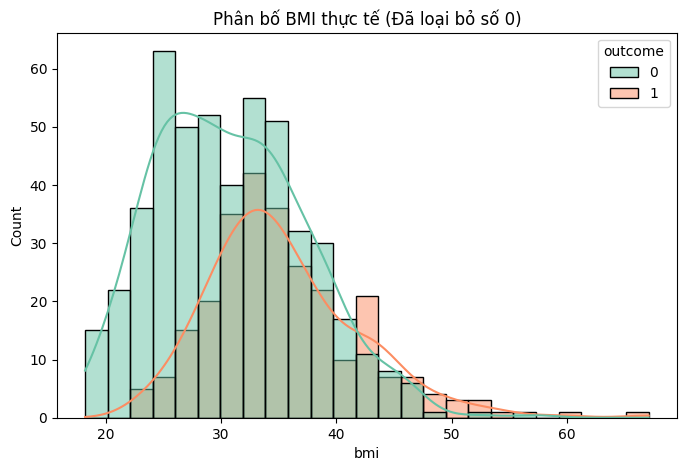

In [70]:
fig_clean, ax_clean = plt.subplots(figsize=(8, 5))
sns.histplot(
    data=df_masked, 
    x="bmi", 
    hue="outcome", 
    kde=True, 
    ax=ax_clean,
    palette="Set2"
)
ax_clean.set_title("Phân bố BMI thực tế (Đã loại bỏ số 0)")
plt.show()

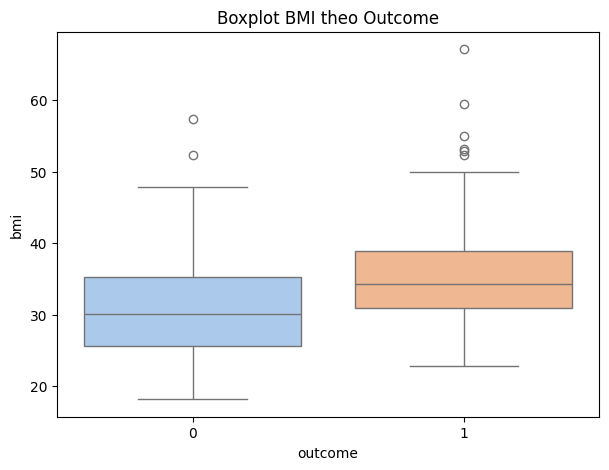

In [71]:
fig_box, ax_box = plt.subplots(figsize=(7, 5))
sns.boxplot(
    data=df_masked,
    x="outcome",
    y="bmi",
    hue="outcome",
    legend=False,
    ax=ax_box,
    palette="pastel"
)
ax_box.set_title("Boxplot BMI theo Outcome")
plt.show()

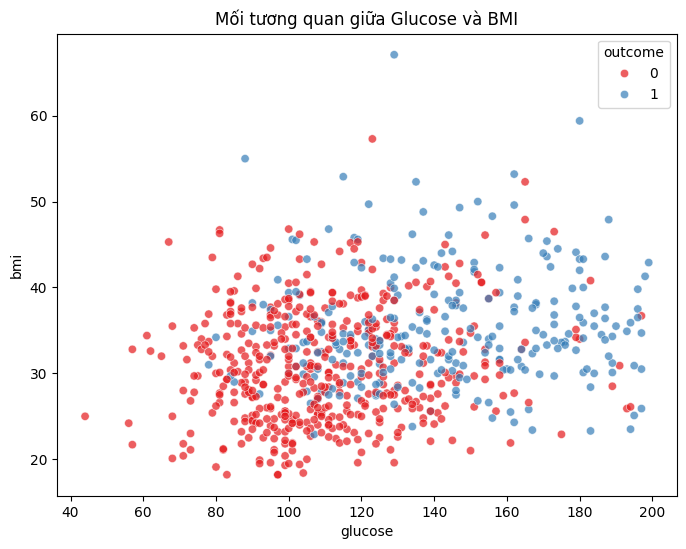

In [72]:
fig_scatter, ax_scatter = plt.subplots(figsize=(8, 6))

plot_df = df_masked.copy()
plot_df['glucose'] = plot_df['glucose'].replace(0, float('nan'))

sns.scatterplot(
    data=plot_df,
    x="glucose",
    y="bmi",
    hue="outcome",
    alpha=0.7,
    ax=ax_scatter,
    palette="Set1"
)
ax_scatter.set_title("Mối tương quan giữa Glucose và BMI")
plt.show()